In [ ]:
#  Install & imports 
!pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [ ]:
# Load data 
df = pd.read_csv('/content/co2_monthly_1987_2026_clean.csv')
df.head()

,Year,Month,Month_Name,Oil,Coal_Lignite,Natural_Gas,Total_CO2
0,1987,1,JAN,2887.26,703.79,522.03,4113.08
1,1987,2,FEB,2506.05,697.51,523.50,3727.06
2,1987,3,MAR,2756.09,686.68,605.84,4048.62
3,1987,4,APR,2699.84,741.40,593.62,4034.86
4,1987,5,MAY,2740.84,1370.03,678.79,4789.66


In [ ]:
#  Aggregate to monthly Total_CO2 
monthly = df.groupby(['Year', 'Month'])['Total_CO2'].sum().reset_index()
monthly = monthly.sort_values(['Year', 'Month']).reset_index(drop=True)
monthly

,Year,Month,Total_CO2
0,1987,1,4113.08
1,1987,2,3727.06
2,1987,3,4048.62
3,1987,4,4034.86
4,1987,5,4789.66
...,...,...,...
466,2025,11,18988.16
467,2025,12,20118.22
468,2026,1,19086.12
469,2026,2,18907.74


In [ ]:
# Build sliding window sequences 
SEQUENCE_LENGTH = 12  # use past 12 months to predict the next month

values = monthly['Total_CO2'].values

X_seq, Y_seq = [], []
for i in range(SEQUENCE_LENGTH, len(values)):
    X_seq.append(values[i - SEQUENCE_LENGTH:i])
    Y_seq.append(values[i])

X_seq = np.array(X_seq)  # shape: (samples, 12)
Y_seq = np.array(Y_seq)

# Reshape for LSTM: (samples, timesteps, features)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

print(f"X shape: {X_seq.shape}")
print(f"Y shape: {Y_seq.shape}")

X shape: (459, 12, 1)
Y shape: (459,)


In [ ]:
# Train / Test split 
# Sequences start from index SEQUENCE_LENGTH in the original monthly df
# So we offset the split index accordingly
split_date_idx = monthly[(monthly['Year'] == 2024) & (monthly['Month'] == 1)].index[0]
split_seq_idx  = split_date_idx - SEQUENCE_LENGTH

X_train_raw, X_test_raw = X_seq[:split_seq_idx], X_seq[split_seq_idx:]
Y_train_raw, Y_test_raw = Y_seq[:split_seq_idx], Y_seq[split_seq_idx:]

print(f"Train sequences: {len(X_train_raw)}")
print(f"Test  sequences: {len(X_test_raw)}")

Train sequences: 432
Test  sequences: 27


In [ ]:
# Feature scaling 
# Scale X (the input sequences)
sc_X = StandardScaler()
X_train_flat = X_train_raw.reshape(-1, 1)
sc_X.fit(X_train_flat)

X_train = sc_X.transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
X_test  = sc_X.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)

# Scale Y (the target)
sc_Y = StandardScaler()
Y_train = sc_Y.fit_transform(Y_train_raw.reshape(-1, 1))
Y_test_scaled = sc_Y.transform(Y_test_raw.reshape(-1, 1))

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

X_train shape: (432, 12, 1)
X_test  shape: (27, 12, 1)


In [ ]:
# Build the LSTM model 
model = Sequential()

# First LSTM layer — return_sequences=True passes full sequence to next LSTM
model.add(LSTM(units=64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)))
model.add(Dropout(0.2))

# Second LSTM layer — return_sequences=False because Dense layers follow
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# Output head
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1,  activation='linear'))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Early stopping callback 
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode='auto',
    restore_best_weights=True
)

In [ ]:
# Train the model ───────────────────────────────────────────────
history = model.fit(
    X_train, Y_train,
    validation_split=0.2,
    batch_size=8,
    epochs=100,
    callbacks=[early_stopping]   # note: list, not bare object
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.2840 - mean_absolute_error: 0.3741 - val_loss: 0.0395 - val_mean_absolute_error: 0.1588
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0486 - mean_absolute_error: 0.1714 - val_loss: 0.0367 - val_mean_absolute_error: 0.1521
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0415 - mean_absolute_error: 0.1625 - val_loss: 0.0310 - val_mean_absolute_error: 0.1362
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0402 - mean_absolute_error: 0.1537 - val_loss: 0.0298 - val_mean_absolute_error: 0.1342
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0363 - mean_absolute_error: 0.1500 - val_loss: 0.0327 - val_mean_absolute_error: 0.1407
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0342 - mean_absolute_error: 0.1442 - val_loss: 0.0314 - val_mean_absolute_error: 0.1402
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0287 - mean_absolute_error: 0.1348 - v

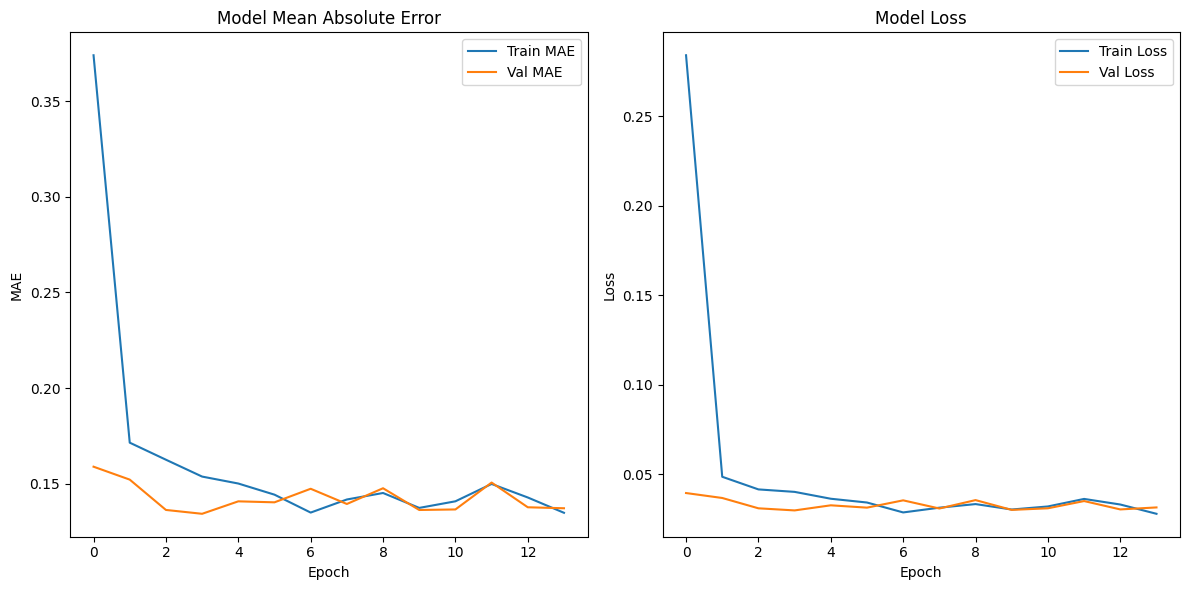

In [ ]:
# Training curves 
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['mean_absolute_error'],     label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Val MAE')
plt.title('Model Mean Absolute Error')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Predictions & inverse transform 
# Test predictions
Y_pred_scaled = model.predict(X_test)
Y_pred        = sc_Y.inverse_transform(Y_pred_scaled)
Y_test_actual = Y_test_raw   # already in original scale

# Train predictions (to check overfitting)
Y_train_pred_scaled = model.predict(X_train)
Y_train_pred        = sc_Y.inverse_transform(Y_train_pred_scaled)
Y_train_actual      = Y_train_raw

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [ ]:
# Cell 12: Metrics
train_r2   = r2_score(Y_train_actual, Y_train_pred)
test_r2    = r2_score(Y_test_actual,  Y_pred)
train_mape = mean_absolute_percentage_error(Y_train_actual, Y_train_pred)
test_mape  = mean_absolute_percentage_error(Y_test_actual,  Y_pred)

# Naive baseline: last value in each sequence = previous month (equivalent to lag1)
naive_pred = X_test_raw[:, -1, 0]
naive_r2   = r2_score(Y_test_actual, naive_pred)
naive_mape = mean_absolute_percentage_error(Y_test_actual, naive_pred)

print(f"Train  R2:  {train_r2:.4f}    Train MAPE:  {train_mape*100:.2f}%")
print(f"Test   R2:  {test_r2:.4f}    Test  MAPE:  {test_mape*100:.2f}%")
print(f"Overfit gap (Train R2 - Test R2): {train_r2 - test_r2:.4f}")
print()
print(f"Naive baseline (lag1) — R2: {naive_r2:.4f},  MAPE: {naive_mape*100:.2f}%")
print(f"LSTM improvement      — R2: +{test_r2 - naive_r2:.4f},  MAPE: -{(naive_mape - test_mape)*100:.2f}pp")

Train  R2:  0.9716    Train MAPE:  5.59%
Test   R2:  -0.0609    Test  MAPE:  3.74%
Overfit gap (Train R2 - Test R2): 1.0325

Naive baseline (lag1) — R2: -0.4202,  MAPE: 4.26%
LSTM improvement      — R2: +0.3593,  MAPE: -0.52pp


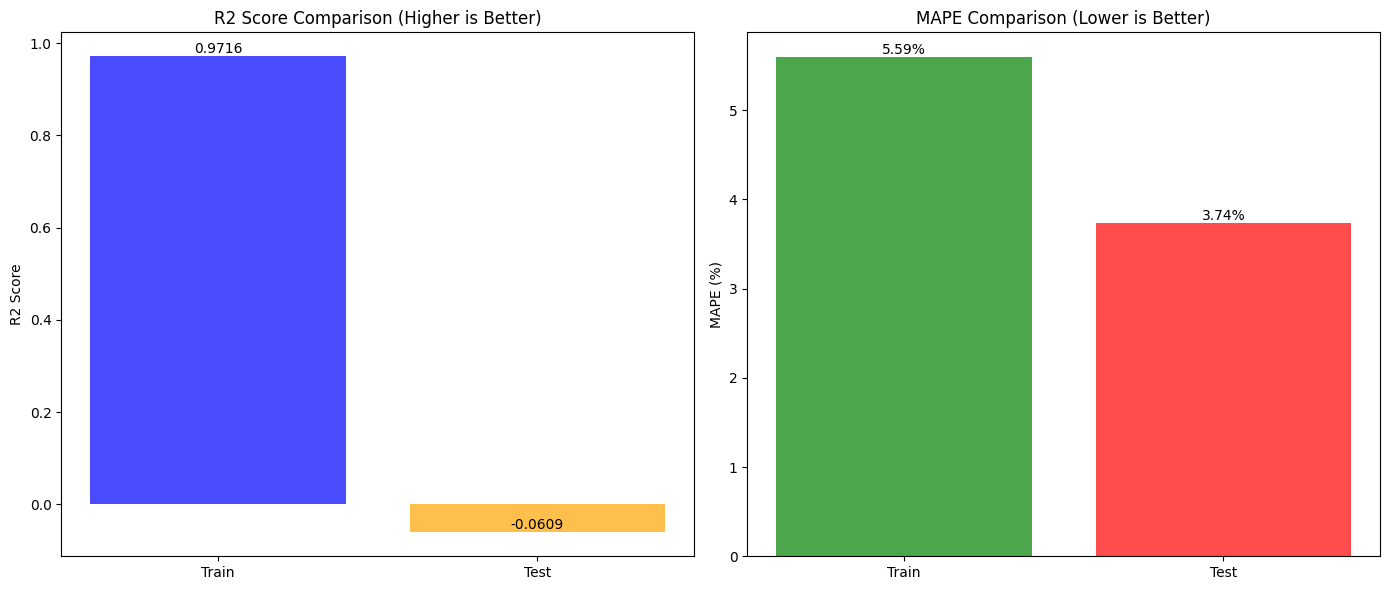

In [ ]:
# Cell 13: R2 & MAPE bar chart comparison 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# R2 comparison
ax1.bar(['Train', 'Test'], [train_r2, test_r2], color=['blue', 'orange'], alpha=0.7)
ax1.set_title('R2 Score Comparison (Higher is Better)')
ax1.set_ylabel('R2 Score')
for i, v in enumerate([train_r2, test_r2]):
    ax1.text(i, v, f'{v:.4f}', ha='center', va='bottom')

# MAPE comparison
ax2.bar(['Train', 'Test'], [train_mape*100, test_mape*100], color=['green', 'red'], alpha=0.7)
ax2.set_title('MAPE Comparison (Lower is Better)')
ax2.set_ylabel('MAPE (%)')
for i, v in enumerate([train_mape*100, test_mape*100]):
    ax2.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

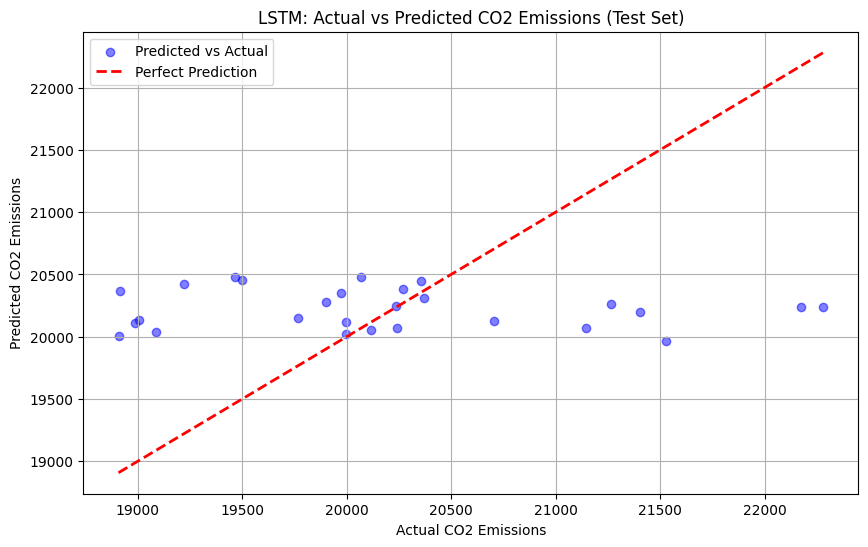

In [ ]:
# Actual vs Predicted scatter 
plt.figure(figsize=(10, 6))
plt.scatter(Y_test_actual, Y_pred, alpha=0.5, color='blue', label='Predicted vs Actual')
plt.plot(
    [Y_test_actual.min(), Y_test_actual.max()],
    [Y_test_actual.min(), Y_test_actual.max()],
    'r--', lw=2, label='Perfect Prediction'
)
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('LSTM: Actual vs Predicted CO2 Emissions (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

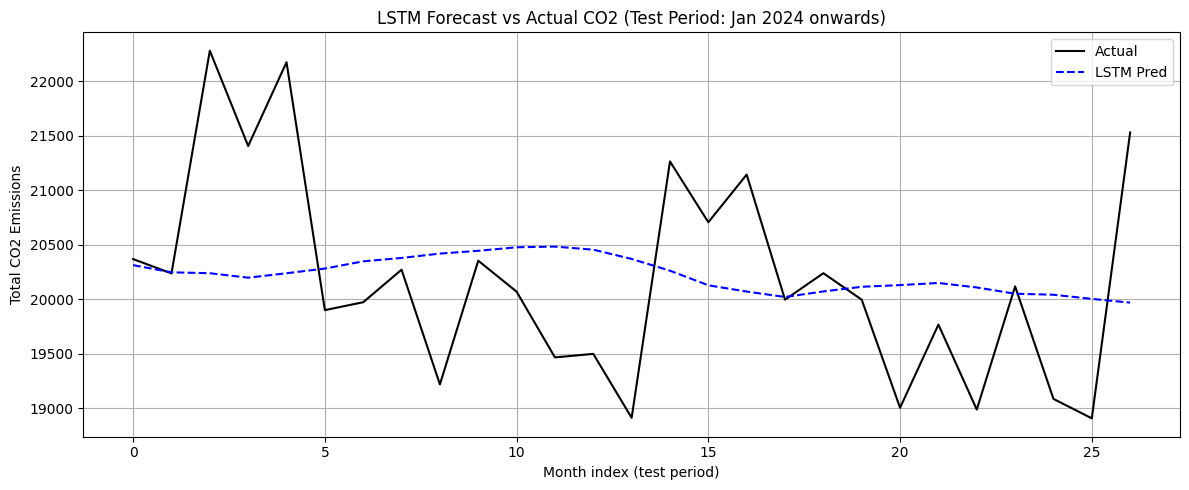

In [ ]:
# Time series plot of actual vs predicted 
# This is more informative than scatter for a time series model
test_months = monthly.iloc[split_date_idx:].reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(range(len(Y_test_actual)), Y_test_actual,        label='Actual',    color='black')
plt.plot(range(len(Y_pred)),        Y_pred.flatten(),     label='LSTM Pred', color='blue', linestyle='--')
plt.title('LSTM Forecast vs Actual CO2 (Test Period: Jan 2024 onwards)')
plt.xlabel('Month index (test period)')
plt.ylabel('Total CO2 Emissions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()